In [31]:
from src.api.option_fetcher import OptionFetcher
from src.analysis.volatility_smile import VolatilitySmileAnalyzer
from dotenv import load_dotenv
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [32]:
import importlib
import src.api.option_fetcher as option_fetcher
import src.analysis.volatility_smile as volatility_smile

importlib.reload(option_fetcher)
OptionFetcher = option_fetcher.OptionFetcher

importlib.reload(volatility_smile)
VolatilitySmileAnalyzer = volatility_smile.VolatilitySmileAnalyzer

In [19]:
load_dotenv()
api_key = os.getenv("API_KEY")
secret_key = os.getenv("SECRET_KEY")

In [20]:
ticker = "SPY"
expiration_dates = ["2026-05-22","2026-05-29","2026-06-05","2026-06-12","2026-06-19","2026-06-26","2026-07-03","2026-07-10","2026-07-17","2026-07-24","2026-07-31"]
spot_delta = 20

In [21]:
fetcher = OptionFetcher(api_key, secret_key)

In [22]:
spot_price = fetcher.get_spot_price(ticker)
df = fetcher.build_options_df(ticker,expiration_dates,spot_delta,100)
df

,symbol,strike,expiry,type,bid,ask,mid,spread,timestamp
0,SPY260522C00729000,729.0,2026-05-22,call,21.14,21.50,21.320,0.36,2026-05-14 19:59:59.528413+00:00
1,SPY260522C00730000,730.0,2026-05-22,call,20.35,20.91,20.630,0.56,2026-05-14 19:59:59.611997+00:00
2,SPY260522C00731000,731.0,2026-05-22,call,19.08,19.65,19.365,0.57,2026-05-14 19:59:59.469001+00:00
3,SPY260522C00732000,732.0,2026-05-22,call,18.37,18.92,18.645,0.55,2026-05-14 19:59:59.462477+00:00
4,SPY260522C00733000,733.0,2026-05-22,call,18.02,18.25,18.135,0.23,2026-05-14 19:59:59.640475+00:00
...,...,...,...,...,...,...,...,...,...
437,SPY260731P00764000,764.0,2026-07-31,put,27.39,28.01,27.700,0.62,2026-05-14 19:59:59.680906+00:00
438,SPY260731P00765000,765.0,2026-07-31,put,27.52,28.68,28.100,1.16,2026-05-14 19:59:59.925539+00:00
439,SPY260731P00766000,766.0,2026-07-31,put,28.15,29.11,28.630,0.96,2026-05-14 19:59:59.612297+00:00
440,SPY260731P00767000,767.0,2026-07-31,put,29.23,29.39,29.310,0.16,2026-05-14 19:59:59.715749+00:00


In [33]:
smile = VolatilitySmileAnalyzer(df, spot_price, 0.045)
smile_df = smile.build_smile_data()

In [35]:
smile_df

,implied_vol,strike,expiration_date,time_to_expiry
0,0.176003,729.0,2026-05-22,0.020091
1,0.182473,730.0,2026-05-22,0.020091
2,0.165485,731.0,2026-05-22,0.020091
3,0.170075,732.0,2026-05-22,0.020091
4,0.180858,733.0,2026-05-22,0.020091
...,...,...,...,...
437,0.168445,764.0,2026-07-31,0.211740
438,0.167196,765.0,2026-07-31,0.211740
439,0.166849,766.0,2026-07-31,0.211740
440,0.167557,767.0,2026-07-31,0.211740


In [41]:
expiry_date = "2026-05-29"
target = pd.to_datetime(expiry_date).date()
smile_data_2d = smile_df[smile_df["expiration_date"] == target]

In [42]:
smile_data_2d

,implied_vol,strike,expiration_date,time_to_expiry
80,0.167922,729.0,2026-05-29,0.039256
81,0.166925,730.0,2026-05-29,0.039256
82,0.161656,731.0,2026-05-29,0.039256
83,0.162383,732.0,2026-05-29,0.039256
84,0.158166,733.0,2026-05-29,0.039256
...,...,...,...,...
155,0.131655,764.0,2026-05-29,0.039256
156,0.139086,765.0,2026-05-29,0.039256
157,0.139804,766.0,2026-05-29,0.039256
158,0.135991,767.0,2026-05-29,0.039256


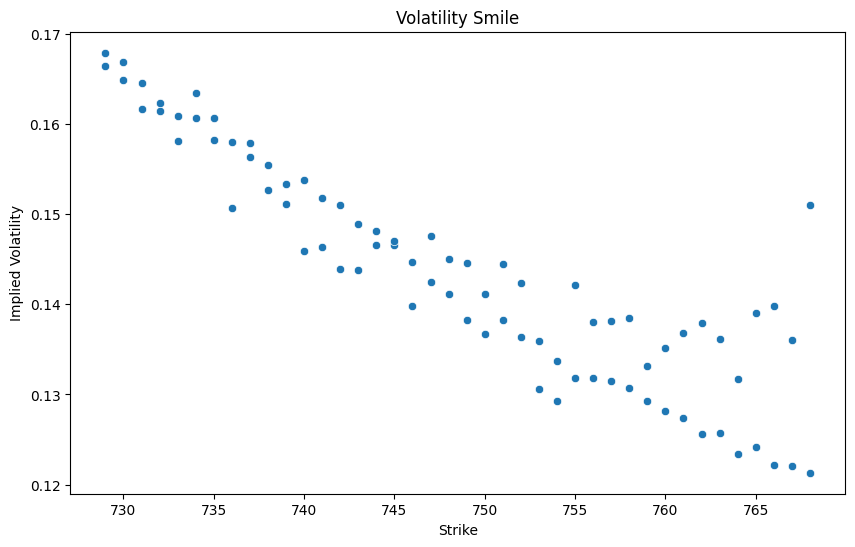

In [43]:
strikes = smile_data_2d["strike"]
implied_vols = smile_data_2d["implied_vol"]
plt.figure(figsize=(10, 6))
sns.scatterplot(x=strikes, y=implied_vols)
plt.xlabel("Strike")
plt.ylabel("Implied Volatility")
plt.title("Volatility Smile")
plt.show()

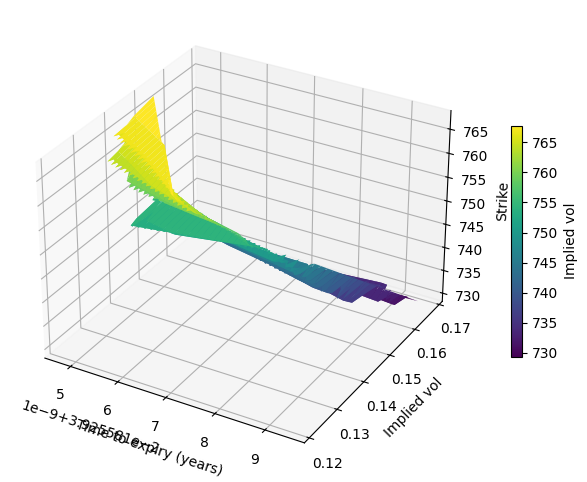

In [49]:
import numpy as np
from scipy.interpolate import griddata
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

df = smile_data_2d.dropna(subset=['strike','implied_vol','time_to_expiry']).copy()

xi = np.linspace(df['time_to_expiry'].min(), df['time_to_expiry'].max(), 80)   # x = time
yi = np.linspace(df['strike'].min(), df['strike'].max(), 80)                   # z = strike
Xi, Yi = np.meshgrid(xi, yi)

Zi = griddata(
    points=(df['time_to_expiry'].values, df['strike'].values),
    values=df['implied_vol'].values,
    xi=(Xi, Yi),
    method='linear'   # 'cubic' may give NaN
)

fig = plt.figure(figsize=(10,6))
ax = fig.add_subplot(111, projection='3d')

# Plot with x=time (Xi), y=implied vol (Zi), z=strike (Yi)
surf = ax.plot_surface(Xi, Zi, Yi, cmap='viridis', edgecolor='none')
ax.set_xlabel('Time to expiry (years)')
ax.set_ylabel('Implied vol')
ax.set_zlabel('Strike')
fig.colorbar(surf, ax=ax, shrink=0.5, label='Implied vol')
ax.view_init(elev=30, azim=-60)
plt.show()

In [ ]:
import numpy as np
from scipy.interpolate import griddata
import plotly.graph_objects as go

df = smile_data_2d.dropna(subset=['strike','implied_vol','time_to_expiry']).copy()

# grid: Xi=time, Yi=strike
xi = np.linspace(df['time_to_expiry'].min(), df['time_to_expiry'].max(), 80)
yi = np.linspace(df['strike'].min(), df['strike'].max(), 80)
Xi, Yi = np.meshgrid(xi, yi)

# Zi = implied_vol on the grid
Zi = griddata(
    points=(df['time_to_expiry'].values, df['strike'].values),
    values=df['implied_vol'].values,
    xi=(Xi, Yi),
    method='linear'
)

fig = go.Figure(data=go.Surface(
    x=Xi,                # time -> x
    y=Zi,                # implied vol -> y
    z=Yi,                # strike -> z (height)
    surfacecolor=Zi,     # color by implied vol
    colorscale='Viridis',
    cmin=np.nanmin(Zi),
    cmax=np.nanmax(Zi),
))
fig.update_layout(
    scene=dict(
        xaxis_title='Time to expiry (years)',
        yaxis_title='Implied vol',
        zaxis_title='Strike'
    ),
    width=1000, height=700
)
import plotly.io as pio
pio.renderers.default = "browser"
fig.show()

ValueError: Mime type rendering requires nbformat>=4.2.0 but it is not installed